Saving phonic-chemist-509603-v9-6d0523a7b77d.json to phonic-chemist-509603-v9-6d0523a7b77d.json
Connected to project: phonic-chemist-509603-v9
(19110, 6)
Train: (14630, 13) Test: (840, 13)

Store x Dept level -> MAE: 427.6, WMAPE: 0.1016

Category level (LightGBM):
      cat_id      MAE   WMAPE
0      FOODS  18624.6  0.0946
1    HOBBIES    904.5  0.0332
2  HOUSEHOLD   1827.3  0.0259

Prophet reference: FOODS 0.1115, HOUSEHOLD 0.0451, HOBBIES 0.0876


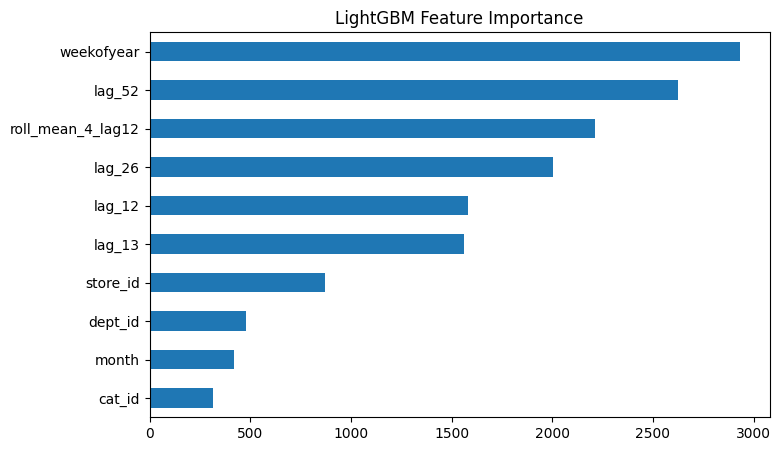

Saved lightgbm_forecasts.csv (840, 14)


In [1]:
!pip install lightgbm -q

from google.colab import files
uploaded = files.upload()

from google.cloud import bigquery
client = bigquery.Client.from_service_account_json(list(uploaded.keys())[0])
print("Connected to project:", client.project)

import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt

# ---- 1. Pull weekly mart + week start dates ----
query = """
SELECT w.wm_yr_wk, c.week_start, w.store_id, w.cat_id, w.dept_id, w.total_units_sold AS y
FROM `phonic-chemist-509603-v9.m5_analytics.mart_weekly_sales` w
JOIN (
    SELECT wm_yr_wk, MIN(date) AS week_start
    FROM `phonic-chemist-509603-v9.m5_raw.calendar`
    GROUP BY wm_yr_wk
) c ON w.wm_yr_wk = c.wm_yr_wk
ORDER BY c.week_start
"""
df = client.query(query).to_dataframe()
df["week_start"] = pd.to_datetime(df["week_start"])
df = df[df["week_start"] < df["week_start"].max()]  # drop last partial week
df = df.sort_values(["store_id", "dept_id", "week_start"]).reset_index(drop=True)
print(df.shape)

# ---- 2. Features (lags >= 12 weeks so the 12-week holdout needs no recursive forecasting) ----
g = df.groupby(["store_id", "dept_id"])["y"]
for lag in [12, 13, 26, 52]:
    df[f"lag_{lag}"] = g.shift(lag)
df["roll_mean_4_lag12"] = g.transform(lambda s: s.shift(12).rolling(4).mean())
df["weekofyear"] = df["week_start"].dt.isocalendar().week.astype(int)
df["month"] = df["week_start"].dt.month
for c in ["store_id", "cat_id", "dept_id"]:
    df[c] = df[c].astype("category")

features = ["store_id", "cat_id", "dept_id", "weekofyear", "month",
            "lag_12", "lag_13", "lag_26", "lag_52", "roll_mean_4_lag12"]

# ---- 3. Train/test split: last 12 weeks held out (same as Prophet) ----
HOLDOUT = 12
cutoff = sorted(df["week_start"].unique())[-HOLDOUT]
train = df[(df["week_start"] < cutoff)].dropna(subset=features)
test = df[df["week_start"] >= cutoff].dropna(subset=features)
print("Train:", train.shape, "Test:", test.shape)

# ---- 4. Train LightGBM ----
model = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, num_leaves=31,
                          random_state=42, verbose=-1)
model.fit(train[features], train["y"])
test = test.copy()
test["pred"] = model.predict(test[features])

# ---- 5. Evaluate: store x dept level, and category level (to compare with Prophet) ----
mae = np.mean(np.abs(test["y"] - test["pred"]))
wmape = np.sum(np.abs(test["y"] - test["pred"])) / np.sum(test["y"])
print(f"\nStore x Dept level -> MAE: {mae:.1f}, WMAPE: {wmape:.4f}")

cat_level = test.groupby(["cat_id", "week_start"], observed=True)[["y", "pred"]].sum().reset_index()
rows = []
for cat, d in cat_level.groupby("cat_id", observed=True):
    rows.append({"cat_id": cat,
                 "MAE": round(np.mean(np.abs(d["y"] - d["pred"])), 1),
                 "WMAPE": round(np.sum(np.abs(d["y"] - d["pred"])) / np.sum(d["y"]), 4)})
print("\nCategory level (LightGBM):")
print(pd.DataFrame(rows))
print("\nProphet reference: FOODS 0.1115, HOUSEHOLD 0.0451, HOBBIES 0.0876")

# ---- 6. Feature importance plot + save outputs ----
imp = pd.Series(model.feature_importances_, index=features).sort_values()
plt.figure(figsize=(8, 5))
imp.plot(kind="barh")
plt.title("LightGBM Feature Importance")
plt.savefig("lightgbm_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

test[["week_start", "store_id", "cat_id", "dept_id", "y", "pred"]].to_csv("lightgbm_forecasts.csv", index=False)
print("Saved lightgbm_forecasts.csv", test.shape)